In [1]:
import numpy as np 
import Physical_Const as phys
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import EoS_ionee as EOS
import ion_electron as ionee
import Cv_star as cv
import ions as ion
import electron_electron as ee
from scipy.optimize import brenth,brentq



#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
sigma    = phys.sigmaSB
me_mev   = phys.me
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu
kappaB   = phys.kappa
Msun     = phys.Msun

h     = hbar*(2.0*np.pi)
me    = me_mev * mevtoerg / c**2
c2    = c*c
arad  = 4.0*sigma / c
Tr    = me * c2 / kappaB
pi05  = np.sqrt(np.pi)
RBohr = hbar**2 / (me*e_erg)


# ---Dimensions---
MA      = 2.0
Sigma02 = ( mu * MA * np.power(me*c/hbar,3) ) / (3 *np.power(np.pi,2))
Rdim    = c / np.sqrt( Sigma02 * G )
Cgrav   = G * Msun / c**2
Mdim    = Rdim / Cgrav
Jdim    = G / c**3

rhobeta=np.log10(3.9e10)

The total free energy $F_{\rm tot}$ of a two component plasma (electrons + ions)  is:
$$F_{\rm tot} = F^{(id)}_{ions} + F^{(id)}_e + F_{\rm ex} $$

where $F^{(id)}$ is the ideal free energy of electrons ans ions, and $F_{\rm ex}$ is the excess free energy arising from interactions:
$$ F_{\rm ex}= F_{ii} + F_{ee} + F_{ie} $$

## Electron Screening in a solid and a coulomb liquid

In [2]:
# Reproducion Figura 3 y 6 de (Chabrier  & Potekhin, 1998)
Ai= 12
Zi =6

xss = np.array( [0.008, 0.0256, 0.0625, 0.1296, 0.24, 0.4])
Nx = len(xss)
rhoii = (xss*RBohr)**(-3)*Ai*mu /(4.0*np.pi*Zi/3)
xT = np.arange(4,10,0.1)
Nt = len(xT)
gammas_nm = np.zeros( (Nx,Nt) )
fie_nm = np.zeros( (Nx,Nt) )

for i in range(Nx):
    for j in range(Nt):
        gammas_nm[i,j] = ionee.Gamma(Ai,Zi,rhoii[i], np.power(10.0,xT[j]) )
        fie_nm[i,j] = ionee.feinm(Ai,Zi,rhoii[i],np.power(10.0,xT[j]))


xr = np.array( [0.3, 0.6, 1.0,2.0, 10.0])
Nx = len(xr)
rhoii = (xr*(me*c/hbar))**(3)*Ai*mu/(Zi*3*np.pi**2)
xT = np.arange(4,10,0.1)
Nt = len(xT)
gammas_m = np.zeros( (Nx,Nt) )
fie_m = np.zeros( (Nx,Nt) )

for i in range(Nx):
    for j in range(Nt):
        gammas_m[i,j] = ionee.Gamma(Ai,Zi,rhoii[i], np.power(10.0,xT[j]) )
        fie_m[i,j] = ionee.feim(Ai,Zi,rhoii[i],np.power(10.0,xT[j]))




Text(0, 0.5, '$log_10 (-f_{ie}/\\Gamma_i) $')

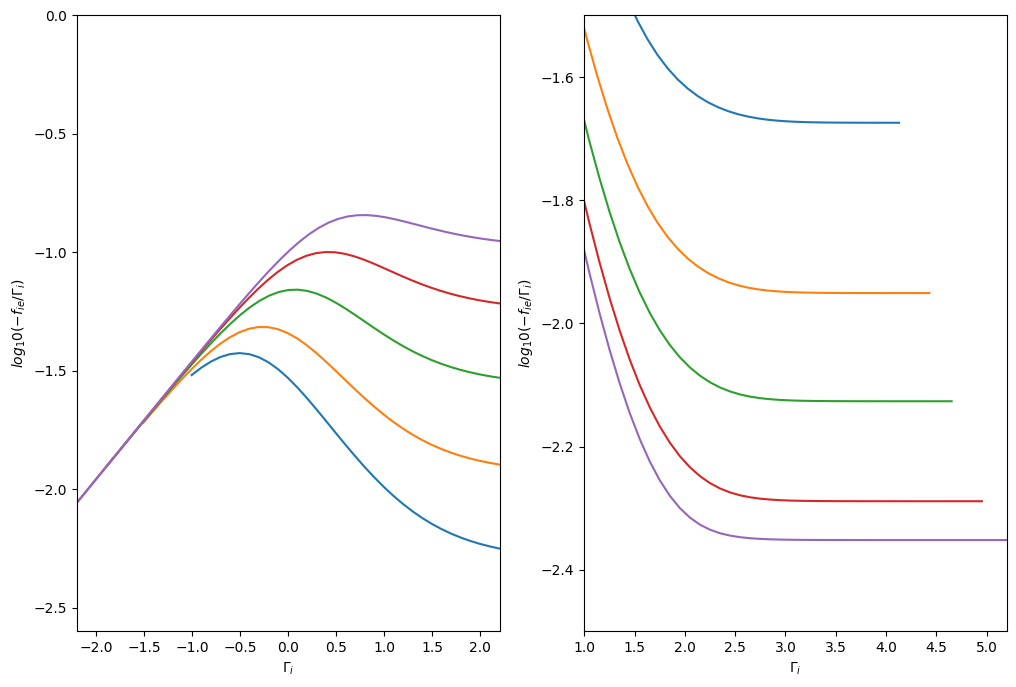

In [3]:
fig= plt.figure(figsize=(12,8))

plt.subplot(121)
for i in range(Nx):
    plt.plot(np.log10(gammas_nm[i,:]), np.log10(-fie_nm[i,:]/gammas_nm[i,:]))

plt.xlim(-2.2,2.2)
plt.ylim(-2.6,0)

plt.xlabel("$\\Gamma_i$")
plt.ylabel("$log_10 (-f_{ie}/\\Gamma_i) $")

plt.subplot(122)


for i in range(Nx):
    plt.plot(np.log10(gammas_m[i,:]), np.log10(-fie_m[i,:]/gammas_m[i,:]))

plt.xlim(1,5.2)
plt.ylim(-2.5,-1.5)

plt.xlabel("$\\Gamma_i$")
plt.ylabel("$log_10 (-f_{ie}/\\Gamma_i) $")



## ions ( Solid OCP [one component plasma] )

In [4]:
from scipy.optimize import fsolve

def space_par(p,etap, gammap):
    rhoi, Ti = np.power(10.0, p)
    eq1 = gammap - ion.Gamma(Ai,Zi,rhoi,Ti)
    eq2 = etap - ion.eta(Ai,Zi,rhoi,Ti)

    return [eq1, eq2]

etai = np.arange(0.1,100,0.1)
NN = len(etai)
xx_param = np.zeros((NN,2))
CVii = np.zeros(NN)

for i in range(NN):
    xx_param[i] = fsolve(space_par, [9, 1], args=(etai[i],180.0))
    rhoi, Ti = np.power(10.0, xx_param[i])
    
    CVii[i]= ion.Cviim_ion(Ai,Zi,rhoi,Ti)

/tmp/ipykernel_37554/3419281244.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 110)


Text(0.5, 1.0, 'ion-ion interaction (harmonic contribution)')

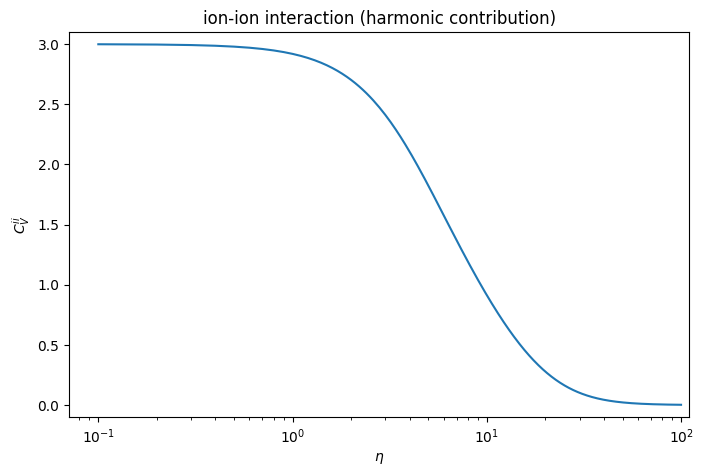

In [5]:
fig= plt.figure(figsize=(8,5))

plt.semilogx(etai, CVii+1.5)

plt.xlim(0, 110)
plt.ylim(-0.1, 3.1)

plt.xlabel("$\\eta$")
plt.ylabel("$C_V^{ii} $")

plt.title("ion-ion interaction (harmonic contribution)")



In [6]:
gammas = np.arange(10,200,1)
NN = len(gammas)
rhoi = 1e9

def space_par(p, gammap):
    Ti = np.power(10.0, p)
    eq1 = gammap - ion.Gamma(Ai,Zi,rhoi,Ti)
   
    return eq1

xT = np.zeros((NN))
Fii = np.zeros((2,NN))

for i in range(NN):
    xT[i] = brentq(space_par ,2,12,args=(gammas[i]))#fsolve(space_par, [5], args=(gammas[i]) )
    Ti = np.power(10.0, xT[i])
    gamma = ion.Gamma(Ai,Zi,rhoi,Ti)
    
    Fii[0,i] = ion.fiim(Ai,Zi,rhoi,Ti) + ionee.feim(Ai,Zi,rhoi,Ti)
    Fii[1,i] = ion.fiinm(gamma) + ionee.feinm(Ai,Zi,rhoi,Ti)

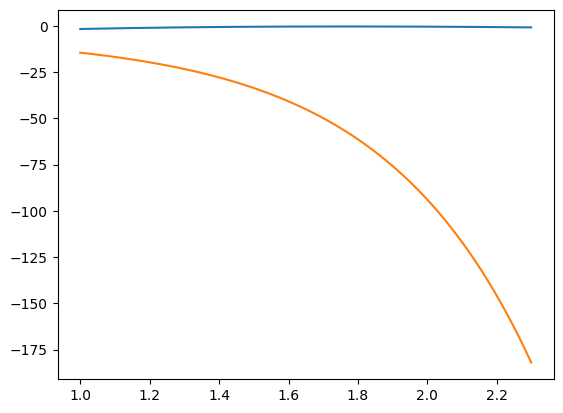

In [7]:
plt.plot( np.log10(gammas), Fii[0,:])
plt.plot( np.log10(gammas), Fii[1,:])


In [8]:
xrho = np.arange(2,8.1,0.1)
Ti = 1e7
tr = kappaB*Ti/(me*c**2)
gammas=  ionee.Gamma(Ai,Zi,np.power(10.0,xrho), Ti )

NN= len(xrho)

Cvie = np.zeros(NN)
Cvii = np.zeros(NN)
Cvion = np.zeros(NN)
Cve = np.zeros(NN)
Cvee = np.zeros(NN)

for i in range(NN):
    rhoi = np.power(10,xrho[i])
    
    Cvie[i] = ionee.Cvie(Ai,Zi,rhoi, Ti)
    Cvii[i] = ion.Cvii(Ai,Zi,rhoi,Ti) 
    Cve[i] = EOS.Cvienm(Ai,Zi,rhoi,tr)
    Cvion[i] = EOS.cv_ion()
    Cvee[i] = ee.Cveenr(Ai,Zi,rhoi, Ti)


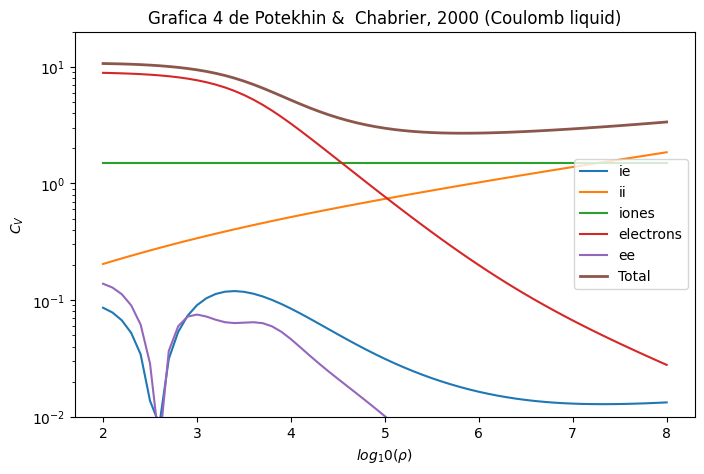

In [9]:
fig= plt.figure(figsize=(8,5))

plt.semilogy( xrho, abs(Cvie), label="ie" )
plt.semilogy( xrho, Cvii, label="ii" )
plt.semilogy( xrho, Cvion,  label="iones")
plt.semilogy( xrho, Cve , label="electrons" )
plt.semilogy( xrho, abs(Cvee) , label="ee" )
plt.semilogy( xrho, Cve + Cvii + Cvion + Cvie , lw=2,label="Total" )

plt.xlabel("$log_10(\\rho)$")
plt.ylabel("$C_V $")

plt.ylim(1e-2, 20)

plt.legend()

plt.title("Grafica 4 de Potekhin &  Chabrier, 2000 (Coulomb liquid)")

plt.show()


In [10]:
xrho = np.arange(2,9,0.05)
Ti = 1e5
tr = kappaB*Ti/(me*c**2)
NN= len(xrho)

Cvie = np.zeros(NN)
Cvii = np.zeros(NN)
Cvion = np.zeros(NN)
Cve = np.zeros(NN)
Cvee = np.zeros(NN)

for i in range(NN):
    rhoi = np.power(10,xrho[i])
    Cvie[i] = ionee.Cvie(Ai,Zi,rhoi, Ti)
    Cvii[i] = ion.Cvii(Ai,Zi,rhoi,Ti) 
    Cvee[i] = ee.Cveenr(Ai,Zi,rhoi, Ti)
    Cve[i] = EOS.Cvienm(Ai,Zi,rhoi,tr)
    Cvion[i] = EOS.cv_ion()
    

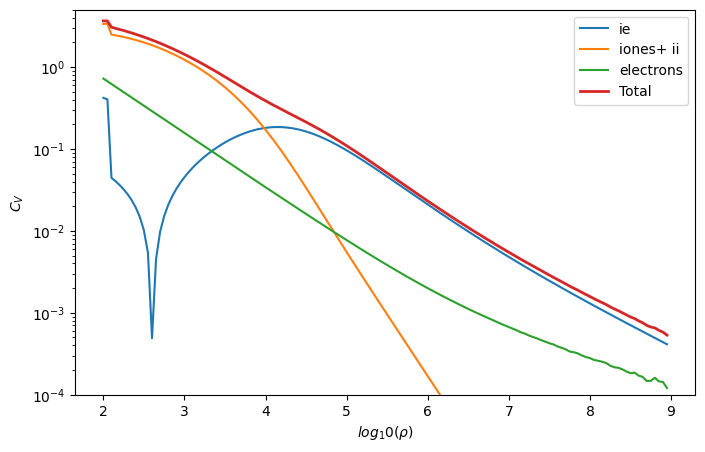

In [11]:
fig= plt.figure(figsize=(8,5))

plt.semilogy( xrho, abs(Cvie), label="ie" )
#plt.semilogy( xrho, Cvii, label="ii" )
plt.semilogy( xrho, Cvion + Cvii,  label="iones+ ii")
plt.semilogy( xrho, Cve , label="electrons" )
plt.semilogy( xrho, Cve + Cvii + Cvion + Cvie , lw=2,label="Total" )

plt.xlabel("$log_10(\\rho)$")
plt.ylabel("$C_V $")

plt.ylim(1e-4, 5)

plt.legend()

In [12]:
Ti = 1e6
tr = kappaB*Ti/(me*c**2)


Cvie = np.zeros(NN)
Cvii = np.zeros(NN)
Cvion = np.zeros(NN)
Cve = np.zeros(NN)
Cvee = np.zeros(NN)

for i in range(NN):
    rhoi = np.power(10,xrho[i])
    Cvie[i] = ionee.Cvie(Ai,Zi,rhoi, Ti)
    Cvii[i] = ion.Cvii(Ai,Zi,rhoi,Ti) 
    Cvee[i] = ee.Cveenr(Ai,Zi,rhoi, Ti)
    Cve[i] = EOS.Cvienm(Ai,Zi,rhoi,tr)
    Cvion[i] = EOS.cv_ion()

    

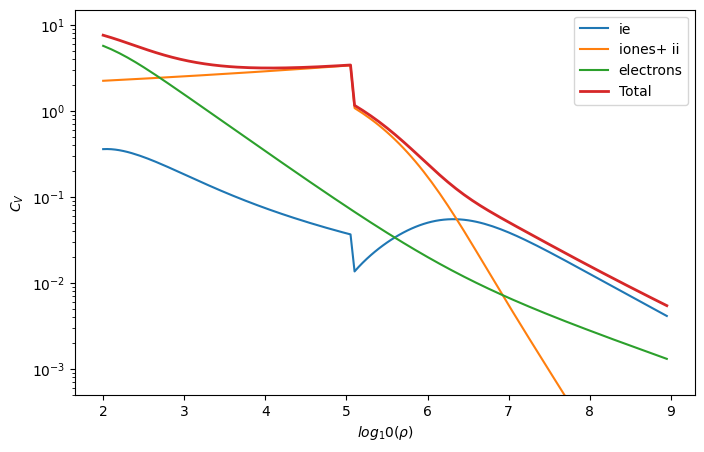

In [13]:
fig= plt.figure(figsize=(8,5))

plt.semilogy( xrho, abs(Cvie), label="ie" )
#plt.semilogy( xrho, Cvii, label="ii" )
plt.semilogy( xrho, Cvion + Cvii,  label="iones+ ii")
plt.semilogy( xrho, Cve , label="electrons" )
plt.semilogy( xrho, Cve + Cvii + Cvion + Cvie , lw=2,label="Total" )

plt.xlabel("$log_10(\\rho)$")
plt.ylabel("$C_V $")

plt.ylim(5e-4, 15)

plt.legend()

In [14]:
rhoi = 1e5
xTi = np.arange(4,8,0.05)
tr = kappaB*Ti/(me*c**2)
NN= len(xTi)
tr = kappaB*np.power(10.0,xTi)/(me*c**2)


Cvie = np.zeros(NN)
Cvii = np.zeros(NN)
Cvion = np.zeros(NN)
Cve = np.zeros(NN)
Cvee = np.zeros(NN)

for i in range(NN):
    Ti = np.power(10,xTi[i])
    Cvie[i] = ionee.Cvie(Ai,Zi,rhoi, Ti)
    Cvii[i] = ion.Cvii(Ai,Zi,rhoi,Ti) 
    Cvee[i] = ee.Cveenr(Ai,Zi,rhoi, Ti)
    Cve[i] = EOS.Cvienm(Ai,Zi,rhoi,tr[i])
    Cvion[i] = EOS.cv_ion()    

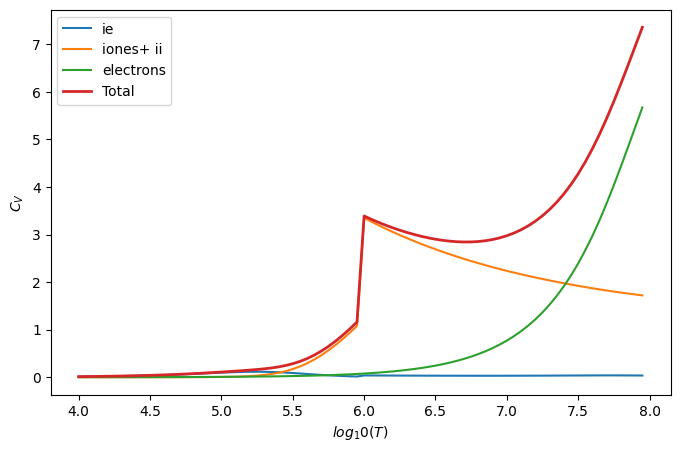

In [15]:
fig= plt.figure(figsize=(8,5))

plt.plot( xTi, abs(Cvie), label="ie" )
#plt.semilogy( xrho, Cvii, label="ii" )
plt.plot( xTi, Cvion + Cvii,  label="iones+ ii")
plt.plot( xTi, Cve , label="electrons" )
plt.plot( xTi, Cve + Cvii + Cvion + Cvie , lw=2,label="Total" )

plt.xlabel("$log_10(T)$")
plt.ylabel("$C_V $")

#plt.ylim(5e-4, 15)

plt.legend()